In [3]:
# ============================================================
# BLOCK 0 - Install the packages we'll need (run once)
# ============================================================
# %pip (not !pip) installs into the exact Python the notebook
# kernel is using, which avoids "installed but still not found".
%pip install openpyxl seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 31.9 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 33.7 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [4]:
# ============================================================
# BLOCK 1 - Imports and loading the Excel file
# ============================================================
# In Codespaces, the notebook runs from the repo root, so the
# Excel file can be read directly by name.
# If openpyxl is missing, uncomment the next line and run once:
# !pip install openpyxl seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

FILE = "NHL_Skaters_2025_2026_Comparison.xlsx"

# header=4 because the real column names are on row 5 in Excel
# (rows 1-4 hold the title and notes)
df = pd.read_excel(FILE, sheet_name="Skater Comparison", header=4)

# Drop any fully empty rows/columns left over from Excel formatting
df = df.dropna(how="all").dropna(axis=1, how="all")

print("Shape:", df.shape)
df.head()

Shape: (1008, 80)


,player,player_key,has_projection,has_actual,has_advanced,proj_FP,actual_FP,error_FP,proj_FP_per_GP,actual_FP_per_GP,proj_GP,actual_GP,error_GP,proj_G,actual_G,error_G,proj_A,actual_A,error_A,proj_PM,actual_PM,error_PM,proj_PPP,actual_PPP,error_PPP,proj_SHP,actual_SHP,error_SHP,proj_SOG,actual_SOG,error_SOG,proj_HIT,actual_HIT,error_HIT,proj_BLK,actual_BLK,error_BLK,proj_age,actual_age,proj_position,actual_position,proj_team,actual_team,proj_TOI_min,actual_TOI_min,proj_PP_TOI_min,actual_SH_pct,actual_PPG,actual_PPA,actual_SHG,actual_SHA,adv_CF,adv_CA,adv_CF_pct,adv_CF_relative_pp,adv_FF,adv_FA,adv_FF_pct,adv_FF_relative_pp,adv_on_ice_SH_pct,adv_on_ice_SV_pct,adv_PDO,adv_off_zone_start_pct,adv_def_zone_start_pct,adv_TOI_per_game_min,adv_EV_TOI_per_game_min,adv_takeaways,adv_giveaways,adv_expected_PM,adv_shot_attempts,adv_through_pct,adv_GP,adv_team,projection_source_row,actual_source_row,advanced_source_row,projection_source_name,actual_source_name,advanced_source_name,advanced_source_id
0,A.J. Greer,ajgreer,1,1,1,157.00,226.50,69.50,1.962500,2.903846,80.0,78.0,-2.0,8.0,17.0,9.0,11.0,15.0,4.0,0.0,14.0,14.0,1.0,1.0,0.0,0.0,0.0,0.0,80.0,104.0,24.0,188.0,203.0,15.0,32.0,29.0,-3.0,29.0,29.0,LW,LW,FLA,FLA,9.45,12.433333,0.20,16.3,1.0,0.0,0.0,0.0,928.0,754.0,55.2,3.9,675.0,555.0,54.9,4.2,12.3,89.5,101.7,56.4,43.6,12.433333,11.750000,9.0,52.0,4.4,207.0,50.2,78.0,FLA,536.0,300.0,358.0,A.J. Greer,A.J. Greer,A.J. Greer,greeraj01
1,Aaron Ekblad,aaronekblad,1,1,1,270.00,207.50,-62.50,3.857143,2.881944,70.0,72.0,2.0,8.0,4.0,-4.0,30.0,22.0,-8.0,9.0,-5.0,-14.0,14.0,5.0,-9.0,1.0,1.0,0.0,139.0,97.0,-42.0,100.0,84.0,-16.0,83.0,103.0,20.0,29.0,29.0,D,D,FLA,FLA,22.89,22.483333,2.20,4.1,1.0,4.0,0.0,1.0,1273.0,1158.0,52.4,0.3,927.0,867.0,51.7,0.8,11.1,88.2,99.3,52.3,47.8,22.483333,17.466667,20.0,68.0,-5.3,241.0,40.2,72.0,FLA,268.0,373.0,261.0,Aaron Ekblad,Aaron Ekblad,Aaron Ekblad,ekblaaa01
2,Adam Fantilli,adamfantilli,1,1,1,328.75,327.50,-1.25,4.009146,3.993902,82.0,82.0,0.0,30.0,24.0,-6.0,28.0,35.0,7.0,-7.0,-13.0,-6.0,10.0,13.0,3.0,0.0,0.0,0.0,206.0,214.0,8.0,116.0,139.0,23.0,55.0,51.0,-4.0,21.0,21.0,C,C,CBJ,CBJ,18.29,18.900000,2.25,11.2,4.0,9.0,0.0,0.0,1387.0,1271.0,52.2,2.4,1014.0,933.0,52.1,2.6,9.7,88.0,97.8,66.4,33.6,18.900000,16.166667,25.0,94.0,3.1,440.0,48.6,82.0,CBJ,102.0,94.0,282.0,Adam Fantilli,Adam Fantilli,Adam Fantilli,fantiad01
3,Adam Fox,adamfox,1,1,1,397.25,284.25,-113.00,5.092949,5.168182,78.0,55.0,-23.0,13.0,9.0,-4.0,58.0,44.0,-14.0,5.0,5.0,0.0,28.0,24.0,-4.0,2.0,1.0,-1.0,138.0,91.0,-47.0,37.0,24.0,-13.0,118.0,74.0,-44.0,27.0,27.0,D,D,NYR,NYR,23.21,23.633333,2.97,9.9,5.0,19.0,0.0,1.0,1180.0,930.0,55.9,10.5,822.0,686.0,54.5,9.2,11.0,89.6,100.6,56.3,43.7,23.633333,19.550000,36.0,65.0,10.9,274.0,33.2,55.0,NYR,45.0,123.0,313.0,Adam Fox,Adam Fox,Adam Fox,foxad01
4,Adam Gaudette,adamgaudette,1,1,1,175.50,151.00,-24.50,2.166667,2.287879,81.0,66.0,-15.0,18.0,17.0,-1.0,12.0,8.0,-4.0,1.0,-9.0,-10.0,7.0,6.0,-1.0,0.0,0.0,0.0,88.0,96.0,8.0,66.0,53.0,-13.0,28.0,33.0,5.0,29.0,29.0,"C,RW",C,SJ,SJS,10.27,11.466667,1.37,17.7,3.0,3.0,0.0,0.0,563.0,721.0,43.8,-3.0,393.0,510.0,43.5,-2.4,10.8,89.4,100.2,34.9,65.1,11.466667,10.466667,13.0,26.0,-4.2,187.0,51.3,66.0,SJS,376.0,393.0,326.0,Adam Gaudette,Adam Gaudette,Adam Gaudette,gaudead01


In [5]:
# ============================================================
# BLOCK 2 - Coverage check
# ============================================================
# has_projection / has_actual / has_advanced = 1 if the player
# exists in that source. Only players with BOTH projection and
# actual stats can be used to train a model.

print(df[["has_projection", "has_actual", "has_advanced"]].value_counts(), "\n")

# The training sample: projected AND observed
m = df[(df["has_projection"] == 1) & (df["has_actual"] == 1)].copy()

# Single position column (actual first, fall back on projected)
m["pos"] = m["actual_position"].fillna(m["proj_position"])
# Group into Forward / Defense, since scoring behaves very differently
m["pos_group"] = np.where(m["pos"] == "D", "D", "F")

print("Matched sample size:", len(m))
print(m["pos"].value_counts())

has_projection  has_actual  has_advanced
1               1           1               416
                0           1               279
0               0           1               226
1               0           0                68
0               1           1                19
Name: count, dtype: int64 

Matched sample size: 416
pos
C     155
D     112
LW     64
RW     63
F      20
W       2
Name: count, dtype: int64


In [6]:
# ============================================================
# BLOCK 3 - Projection accuracy per stat
# ============================================================
# For each stat:
#   r    = correlation projection vs actual (1 = perfect ranking)
#   bias = mean(actual - projection)  (negative = projections too optimistic)
#   MAE  = average absolute miss
#   R2   = share of variance the projection explains

stats = ["FP", "FP_per_GP", "GP", "G", "A", "PM", "PPP", "SHP",
         "SOG", "HIT", "BLK"]

rows = []
for s in stats:
    p, a = m[f"proj_{s}"], m[f"actual_{s}"]
    ok = p.notna() & a.notna()
    r = p[ok].corr(a[ok])
    rows.append({"stat": s, "n": ok.sum(), "r": r, "R2": r**2,
                 "bias": (a[ok] - p[ok]).mean(),
                 "MAE": (a[ok] - p[ok]).abs().mean()})

accuracy = pd.DataFrame(rows).round(3).sort_values("r", ascending=False)
accuracy

,stat,n,r,R2,bias,MAE
10,BLK,416,0.908,0.825,-5.486,12.817
9,HIT,416,0.865,0.748,-7.505,20.885
6,PPP,416,0.836,0.700,-1.291,4.142
4,A,416,0.813,0.661,-0.637,6.373
1,FP_per_GP,416,0.804,0.646,-0.004,0.549
8,SOG,416,0.799,0.639,-6.642,25.844
3,G,416,0.781,0.609,-1.002,4.959
0,FP,416,0.730,0.533,-13.509,53.582
7,SHP,416,0.524,0.274,0.094,0.637
5,PM,416,0.333,0.111,1.072,11.678


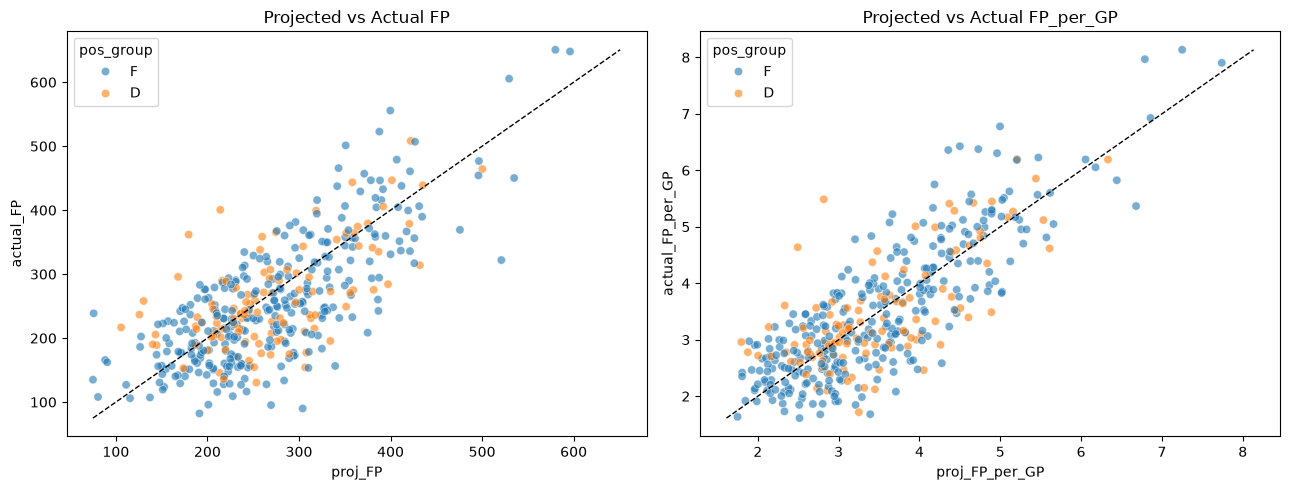

In [7]:
# ============================================================
# BLOCK 4 - Scatter: projected vs actual FP per game
# ============================================================
# Points on the dashed line = perfect projection.
# Look for patterns: are stars over-projected? Are depth
# players under-projected? Do D and F behave differently?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ["FP", "FP_per_GP"]):
    sns.scatterplot(data=m, x=f"proj_{col}", y=f"actual_{col}",
                    hue="pos_group", alpha=0.6, ax=ax)
    lims = [m[[f"proj_{col}", f"actual_{col}"]].min().min(),
            m[[f"proj_{col}", f"actual_{col}"]].max().max()]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"Projected vs Actual {col}")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# BLOCK 5 - Correlation of every numeric column with the target
# ============================================================
# Target = actual_FP_per_GP (per-game rate removes the noise
# from injuries / games missed).
# We exclude error_* columns (they contain the answer) and
# bookkeeping columns (source rows, flags).

TARGET = "actual_FP_per_GP"

exclude = [c for c in m.columns
           if c.startswith("error_") or "source" in c or c.startswith("has_")]
num = m.select_dtypes("number").drop(columns=exclude, errors="ignore")

corr_target = num.corr()[TARGET].drop(TARGET).sort_values(ascending=False)

# Tag each column so we remember what is legal as a predictor
def tag(c):
    if c.startswith("proj_"): return "PRESEASON (usable)"
    if c.startswith("adv_"):  return "post-season advanced"
    return "post-season actual"

corr_df = pd.DataFrame({"corr": corr_target.round(3),
                        "type": [tag(c) for c in corr_target.index]})
corr_df

,corr,type
actual_FP,0.925,post-season actual
actual_A,0.843,post-season actual
proj_FP_per_GP,0.804,PRESEASON (usable)
proj_FP,0.794,PRESEASON (usable)
actual_PPP,0.779,post-season actual
actual_PPA,0.763,post-season actual
proj_A,0.729,PRESEASON (usable)
actual_SOG,0.721,post-season actual
proj_PPP,0.711,PRESEASON (usable)
adv_shot_attempts,0.711,post-season advanced


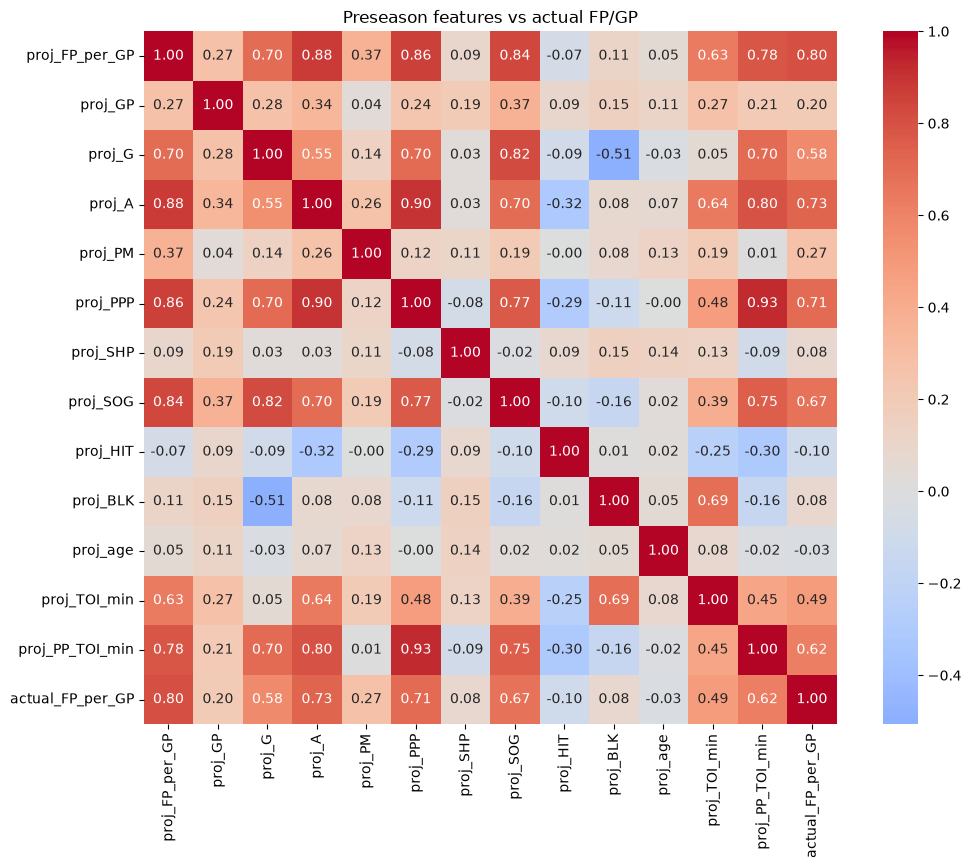

In [9]:
# ============================================================
# BLOCK 6 - Correlation matrix among PRESEASON features only
# ============================================================
# Checks for multicollinearity: if two predictors correlate > 0.85
# (e.g. proj_G and proj_SOG), linear regression struggles to
# separate their effects, so we may drop one or use Ridge/Lasso.

pre_cols = ["proj_FP_per_GP", "proj_GP", "proj_G", "proj_A", "proj_PM",
            "proj_PPP", "proj_SHP", "proj_SOG", "proj_HIT", "proj_BLK",
            "proj_age", "proj_TOI_min", "proj_PP_TOI_min", TARGET]

plt.figure(figsize=(12, 9))
sns.heatmap(m[pre_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True)
plt.title("Preseason features vs actual FP/GP")
plt.show()

In [10]:
# ============================================================
# BLOCK 7 - Missing values + quick distribution summary
# ============================================================
# Tells me whether we need to impute anything before modeling.

miss = m[pre_cols].isna().sum()
print("Missing values in preseason features:\n", miss[miss > 0], "\n")

m[pre_cols].describe().T.round(2)

Missing values in preseason features:
 proj_age    2
dtype: int64 



,count,mean,std,min,25%,50%,75%,max
proj_FP_per_GP,416.0,3.50,1.02,1.75,2.79,3.37,4.12,7.74
proj_GP,416.0,76.76,5.91,36.00,76.00,78.00,80.00,82.00
proj_G,416.0,17.50,9.25,2.00,10.00,16.00,24.00,48.00
proj_A,416.0,27.72,12.61,6.00,19.00,25.00,35.00,91.00
proj_PM,416.0,0.82,8.14,-31.00,-4.25,0.00,5.00,32.00
proj_PPP,416.0,11.74,8.92,0.00,4.00,10.00,18.00,46.00
proj_SHP,416.0,0.65,0.85,0.00,0.00,0.00,1.00,4.00
proj_SOG,416.0,142.63,50.57,41.00,103.75,139.00,175.00,315.00
proj_HIT,416.0,81.06,55.76,4.00,41.00,65.50,107.00,387.00
proj_BLK,416.0,62.09,38.40,13.00,35.00,46.50,83.00,185.00


In [11]:
# ============================================================
# BLOCK 8 - Value Over Replacement Player (VORP)
# ============================================================
# Fantasy value = points ABOVE what you'd get from the best
# undrafted player at that position. League: 12 teams,
# 2C / 2LW / 2RW / 4D / 1 Util (forward-only in practice).

TEAMS = 12
SLOTS = {"C": 2, "LW": 2, "RW": 2, "D": 4}
UTIL = 1

p = df[df["has_projection"] == 1].copy()
p["elig"] = p["proj_position"].str.split(",")   # "C,LW" -> ["C","LW"]
ex = p.explode("elig")                           # one row per eligible position

# Replacement level = FP of the first non-starter at each position.
# The Util slot is spread across C/LW/RW (a forward usually fills it).
repl = {}
for pos, n in SLOTS.items():
    k = int(TEAMS * n + (TEAMS * UTIL / 3 if pos != "D" else 0))
    pool = ex[ex["elig"] == pos].sort_values("proj_FP", ascending=False)
    repl[pos] = pool["proj_FP"].iloc[k]
print("Replacement-level FP by position:", {k: round(v, 1) for k, v in repl.items()})

# A multi-position player is valued at the position where he beats
# replacement by the most (lowest replacement level)
p["replacement"] = p["elig"].apply(lambda L: min(repl[x] for x in L))
p["VORP"] = p["proj_FP"] - p["replacement"]

# Top 40 by value, and how value is spread across positions
cols = ["player", "proj_position", "proj_team", "proj_GP", "proj_FP", "VORP"]
display(p.sort_values("VORP", ascending=False)[cols].head(40).round(1))

print("\nAverage VORP of the top 12 per position (1 per team):")
print(ex.merge(p[["player_key", "VORP"]], on="player_key")
        .groupby("elig")["VORP_y" if "VORP_y" in ex.columns else "VORP"]
        .apply(lambda s: s.nlargest(12).mean()).round(1))

Replacement-level FP by position: {'C': np.float64(356.2), 'LW': np.float64(339.5), 'RW': np.float64(350.0), 'D': np.float64(270.5)}


,player,proj_position,proj_team,proj_GP,proj_FP,VORP
85,Connor McDavid,C,EDM,77.0,596.0,239.8
63,Cale Makar,D,COL,79.0,500.2,229.8
286,Nathan MacKinnon,C,COL,80.0,580.0,223.8
220,Leon Draisaitl,"C,LW",EDM,78.0,535.0,195.5
296,Nikita Kucherov,RW,TB,78.0,529.5,179.5
39,Auston Matthews,C,TOR,78.0,521.0,164.8
412,Zach Werenski,D,CBJ,80.0,435.2,164.8
333,Roman Josi,D,NSH,77.0,432.0,161.5
212,Kirill Kaprizov,LW,MIN,77.0,496.0,156.5
124,Evan Bouchard,D,EDM,81.0,422.0,151.5



Average VORP of the top 12 per position (1 per team):
elig
C     118.5
D     140.5
LW     99.5
RW     84.7
Name: VORP, dtype: float64
